# Exploratory notebook

It shows nearly all opacity curves available in databases overlaid on JWST transmission curves, but it grew out of hand as I discovered more database entries

In [1]:
from brick2221.analysis.analysis_setup import basepath

Set DATE-AVG to '2022-08-28T03:05:32.473' from MJD-AVG.
Set DATE-END to '2022-08-28T03:34:03.557' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -20.661125 from OBSGEO-[XYZ].
Set OBSGEO-H to 1526408297.850 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [2]:
import pylab as pl

In [3]:
from astropy import units as u
import numpy as np
import importlib as imp
import icemodels.core
imp.reload(icemodels.core)
from icemodels.core import (optical_constants_cache_dir,
                            load_molecule,
                            composition_to_molweight,
                            download_all_lida, download_all_ocdb, download_all_univap,
                            load_molecule_univap, read_ocdb_file, read_lida_file, read_univap_file)

download_all_univap(redo=False)

download_all_lida()

download_all_ocdb()

In [4]:
univapmethanol = load_molecule_univap('methanol')
univapmethanol

WaveNum,absorbance,k,n,Wavelength
1 / cm,,,,um
float64,float64,float64,float64,float64
657.9554,0.05246987,0.166806,1.548153,15.198598567623275
658.8875,0.05440833,0.172741,1.545768,15.177097759480942
659.8194,0.05268258,0.167003,1.546967,15.155662291833188
660.7513,0.05633126,0.178444,1.556113,15.134287287819182
661.6833,0.06115137,0.193483,1.549996,15.112970207952959
662.6152,0.06413776,0.202544,1.529111,15.09171537266275
663.5472,0.05839282,0.183925,1.516773,15.070517967674341
664.4791,0.0578868,0.182122,1.523771,15.049382290579192


In [5]:
univapco = load_molecule_univap('CO')
univapco.meta

{'density': <Quantity 1. g / cm3>,
 'author': 'Rocha & Pilling\n(2014), Ehrenfreund et al. 1999',
 'source': 'http://www1.univap.br/gaa/nkabs-database/G1.txt',
 'temperature': 10,
 'molecule': 'CO',
 'composition': 'CO',
 'molwt': <Quantity 28. u>,
 'database': 'univap',
 'filename': '/red/adamginsburg/repos/icemodels/icemodels/data/univap_G1_CO_10_Rocha_&_Pilling_(2014),_Ehrenfreund_et_al._1999.txt'}

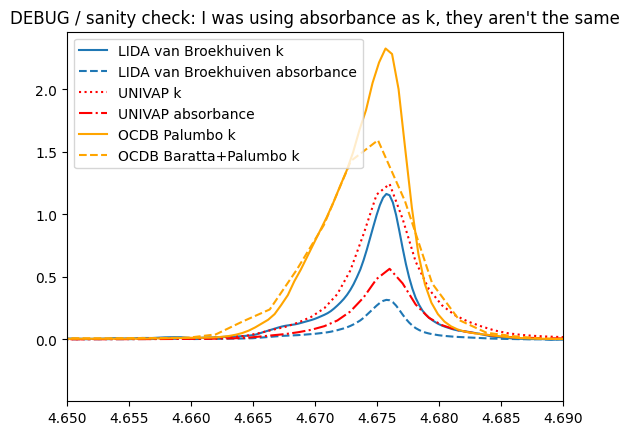

In [6]:
univapco = load_molecule_univap('CO')
palu = read_ocdb_file(f'{optical_constants_cache_dir}/267_CO_(1)_15K_Palumbo.txt')
#fras = read_lida_file(f'{optical_constants_cache_dir}/61_CO_1_15.0K.txt')
broek = read_lida_file(f'{optical_constants_cache_dir}/75_CO_1_15.0K.txt')
baratta = read_ocdb_file(f'{optical_constants_cache_dir}/ocdb_1_CO_(1)_12.5K_Baratta.txt')
#pl.plot(fras['Wavelength'], fras['k'])
pl.plot(broek['Wavelength'], broek['k'], label='LIDA van Broekhuiven k')
pl.plot(broek['Wavelength'], broek['absorbance'], label='LIDA van Broekhuiven absorbance')
pl.plot(univapco['Wavelength'], univapco['k'], label='UNIVAP k', color='r')
pl.plot(univapco['Wavelength'], univapco['absorbance'], label='UNIVAP absorbance', color='r')
pl.plot(palu['Wavelength'], palu['k'], color='orange', label='OCDB Palumbo k')
pl.plot(baratta['Wavelength'], baratta['k'], color='orange', label='OCDB Baratta+Palumbo k')
pl.legend(loc='best')
pl.xlim(4.65, 4.69);
pl.title("DEBUG / sanity check: I was using absorbance as k, they aren't the same");

In [7]:
# compare LIDA optcon to LIDA absorbance, interpreted by us
lida_ehr_coco2_optcon = read_lida_file(f'{optical_constants_cache_dir}/lida_optcon_5_CO_CO2_(100_70)_10.0K_k.txt')
lida_ehr_coco2 = read_lida_file(f'{optical_constants_cache_dir}/lida_124_CO:CO2_(100:70)_10.0K.txt', ice_thickness=250)

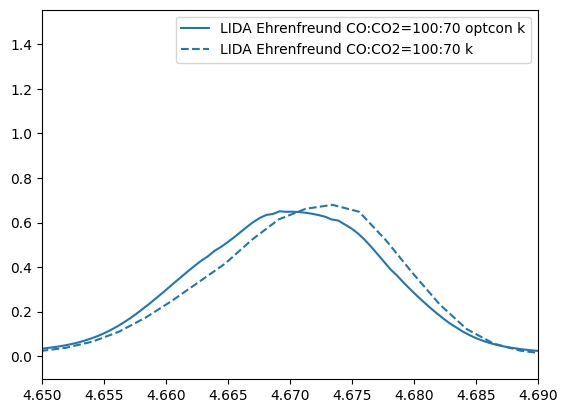

In [8]:
pl.plot(lida_ehr_coco2_optcon['Wavelength'], lida_ehr_coco2_optcon['k'], label='LIDA Ehrenfreund CO:CO2=100:70 optcon k')
pl.plot(lida_ehr_coco2['Wavelength'], lida_ehr_coco2['k'], label='LIDA Ehrenfreund CO:CO2=100:70 k')
pl.legend(loc='best')
pl.xlim(4.65, 4.69);

# Load tables

In [9]:
optical_constants_cache_dir

'/red/adamginsburg/repos/icemodels/icemodels/data'

In [10]:
ls $optical_constants_cache_dir

'100_C3H6O:CO_(1:5)_15.0K.txt'
'100_C3H6O:CO_(1:5)_30.0K.txt'
'100_CO:CH4_(20:1)_20K_Hudgins.txt'
'101_C3H6O:CO_(1:20)_15.0K.txt'
'101_C3H6O:CO_(1:20)_30.0K.txt'
'101_CO:CH4_(20:1)_25K_Hudgins.txt'
'102_C3H6O:CO2_(1:5)_100.0K.txt'
'102_C3H6O:CO2_(1:5)_15.0K.txt'
'102_C3H6O:CO2_(1:5)_30.0K.txt'
'102_C3H6O:CO2_(1:5)_70.0K.txt'
'102_C3H6O:CO2_(1:5)_90.0K.txt'
'102_CO:OCS_(20:1)_10K_Hudgins.txt'
'103_C3H6O:CO2_(1:20)_100.0K.txt'
'103_C3H6O:CO2_(1:20)_15.0K.txt'
'103_C3H6O:CO2_(1:20)_30.0K.txt'
'103_C3H6O:CO2_(1:20)_70.0K.txt'
'103_C3H6O:CO2_(1:20)_90.0K.txt'
'103_CO:OCS_(20:1)_20K_Hudgins.txt'
'104_C3H6O:CH3OH_(1:5)_100.0K.txt'
'104_C3H6O:CH3OH_(1:5)_110.0K.txt'
'104_C3H6O:CH3OH_(1:5)_120.0K.txt'
'104_C3H6O:CH3OH_(1:5)_140.0K.txt'
'104_C3H6O:CH3OH_(1:5)_15.0K.txt'
'104_C3H6O:CH3OH_(1:5)_30.0K.txt'
'104_C3H6O:CH3OH_(1:5)_70.0K.txt'
'104_C3H6O:CH3OH_(1:5)_90.0K.txt'
'104_CO:OCS_(20:1)_25K_Hudgins.txt'
'105_C3H6O:CH3OH_(1:20)_100.0K.txt'
'105_C3H6O:CH3OH_(1:20)_110.0K.txt'
'105_C3H6O:CH3OH_(1

In [11]:
import glob

{key: tb.colnames for key, tb in tbs.items()}

## Plot CO absorbance profiles

In [12]:
palumbo = load_molecule('co')

In [13]:
from astroquery.svo_fps import SvoFps
instrument = 'NIRCam'
telescope = 'JWST'
filt444 = 'F444W'
filt356 = 'F356W'
filt466 = 'F466N'
filt410 = 'F410M'
filt430 = 'F430M'
filt470 = 'F470N'
wavelength_table_466 = SvoFps.get_transmission_data(f'{telescope}/{instrument}.{filt466}')
wavelength_table_410 = SvoFps.get_transmission_data(f'{telescope}/{instrument}.{filt410}')
wavelength_table_430 = SvoFps.get_transmission_data(f'{telescope}/{instrument}.{filt430}')
wavelength_table_444 = SvoFps.get_transmission_data(f'{telescope}/{instrument}.{filt444}')
wavelength_table_356 = SvoFps.get_transmission_data(f'{telescope}/{instrument}.{filt356}')

In [14]:
#from brick2221.analysis.co_ice_absorbance_models import load_tables
imp.reload(icemodels.core)
imp.reload(icemodels.absorbance_in_filters)
from icemodels.absorbance_in_filters import load_tables
cotbs, h2otbs, co2tbs = load_tables(cache=locals())

  0%|          | 0/887 [00:00<?, ?it/s]

Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/25_H2O:C^18O2_1:1_15.0K.txt


/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/astropy/units/equivalencies.py:167: RuntimeWarning: divide by zero encountered in divide
  (si.m, inv_m_spec, lambda x: 1.0 / x),


Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/lida_20_H2O:C^18O2_2:1_45.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/19_H2O:C^18O2_2:1_75.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/22_H2O:C^18O2_1:2_45.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/21_H2O:C^18O2_1:1_75.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/lida_19_H2O:C^18O2_2:1_75.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/lida_19_H2O:C^18O2_2:1_135.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/lida_20_H2O:C^18O2_2:1_135.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/24_H2O:C^18O2_1:4_135.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/23_H2O:C^18O2_4:1_135.0K.txt
Ice thickness is None for /red/adamginsburg/repos

  0%|          | 0/693 [00:00<?, ?it/s]

Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/lida_64_CO:CH3OH_1:1_90.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/lida_64_CO:CH3OH_1:1_145.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/lida_60_CO:CO2_1:1_100.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/64_CO:CH3OH_1:1_25.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/lida_60_CO:CO2_1:1_18.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/64_CO:CH3OH_1:1_22.5K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/lida_64_CO:CH3OH_1:1_15.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/64_CO:CH3OH_1:1_70.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/lida_64_CO:CH3OH_1:1_130.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/ic

  0%|          | 0/443 [00:00<?, ?it/s]

Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/lida_63_CO2_1_25.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/63_CO2_1_80.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/63_CO2_1_22.5K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/63_CO2_1_40.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/63_CO2_1_25.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/63_CO2_1_28.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/63_CO2_1_35.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/63_CO2_1_20.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/63_CO2_1_15.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemodels/icemodels/data/63_CO2_1_30.0K.txt
Ice thickness is None for /red/adamginsburg/repos/icemo

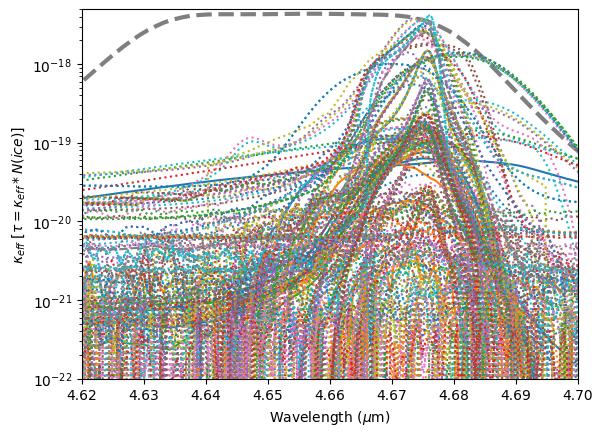

In [15]:
for ii, (key, tb) in enumerate(cotbs.items()):
    #if key in (('ocdb', 64), ('ocdb', 63)):
        # bad - temporary
        #continue

    try:
        molwt = u.Quantity(composition_to_molweight(tb.meta['composition']), u.Da)
    except Exception as ex:
        molwt = u.Quantity(composition_to_molweight(tb.meta['compound_name']), u.Da)
    
    kk = tb['k₁'] if 'k₁' in tb.colnames else tb['k']
    opacity = ((kk.quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (molwt)))).to(u.cm**2)
    pl.plot(tb['Wavelength'], 
            opacity,
            label=f'{key}: {tb.meta["author"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                    if 'author' in tb.meta else
                  f'{key}: {tb.meta["index"]} {tb.meta["molecule"]} {tb.meta["ratio"]} {tb.meta["temperature"]}',
            linestyle='-' if ii<10 else ':')
pl.plot(palumbo['Wavelength'],
        (palumbo['k']* palumbo['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da))).to(u.cm**2),
        linestyle='--',
        label='Palumbo')

_, ymax = pl.ylim()
xarr = wavelength_table_466['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_466['Transmission']/wavelength_table_466['Transmission'].max() * ymax,
        color='k', linewidth=3, alpha=0.5, zorder=-5)

pl.semilogy();
pl.ylim(1e-22, 5e-18);

#pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.5,0.2,), fontsize=8);
pl.xlim(4.62, 4.70);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");

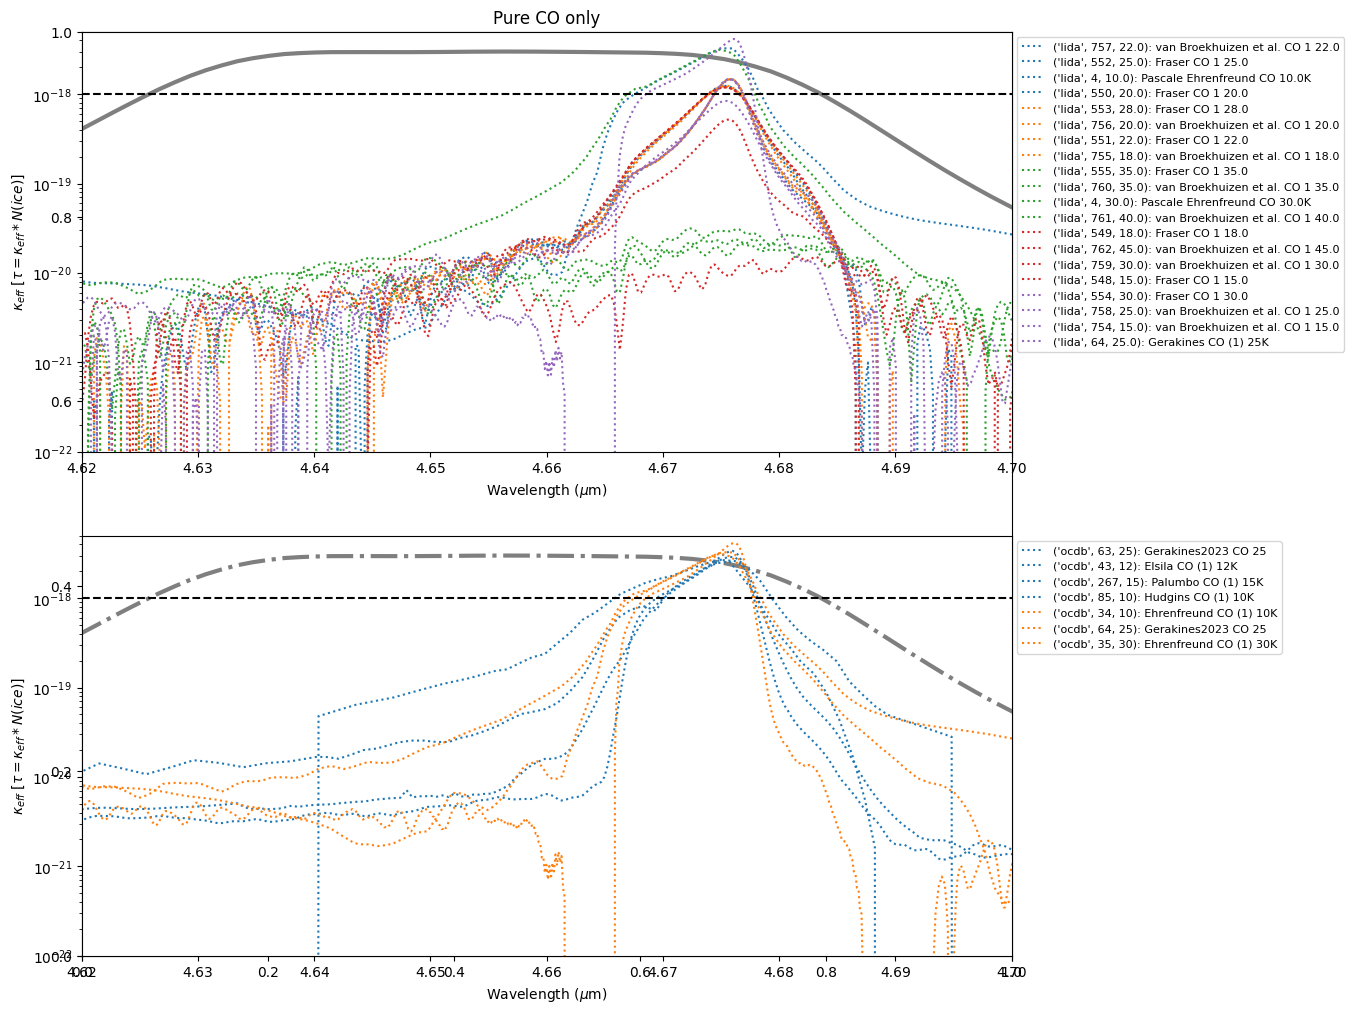

In [16]:
# pure CO only
pl.figure(figsize=(12, 12))
pl.title("Pure CO only")
for ii, (key, tb) in enumerate(cotbs.items()):
    if ':' in tb.meta['composition'] or tb.meta['composition'].count(' ') > 1:
        continue
    
    molwt = u.Quantity(composition_to_molweight(tb.meta['composition']), u.Da)
    
    kk = tb['k₁'] if 'k₁' in tb.colnames else tb['k']
    opacity = ((kk.quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (molwt)))).to(u.cm**2)
    if key[0] == 'lida':
        pl.subplot(2,1,1)
    elif key[0] == 'ocdb':
        pl.subplot(2,1,2)
        
    pl.plot(tb['Wavelength'], 
            opacity,
            label=f'{key}: {tb.meta["author"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                    if 'author' in tb.meta else
                  f'{key}: {tb.meta["index"]} {tb.meta["molecule"]} {tb.meta["ratio"]} {tb.meta["temperature"]}',
            linestyle='-' if ii<10 else ':')


for ii in (1,2):
    pl.subplot(2, 1, ii)
    ymax = 3e-18

    xarr = wavelength_table_466['Wavelength'].quantity.to(u.um)
    pl.plot(xarr, wavelength_table_466['Transmission']/wavelength_table_466['Transmission'].max() * ymax,
            color='k', linewidth=3, alpha=0.5, zorder=-5)

    pl.axhline(1e-18, color='k', linestyle='--');
    
    pl.semilogy();
    pl.ylim(1e-22, 5e-18);
    
    pl.legend(loc='upper left', bbox_to_anchor=(1.,1,), fontsize=8);
    pl.xlim(4.62, 4.70);
    pl.xlabel("Wavelength ($\\mu$m)")
    pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");

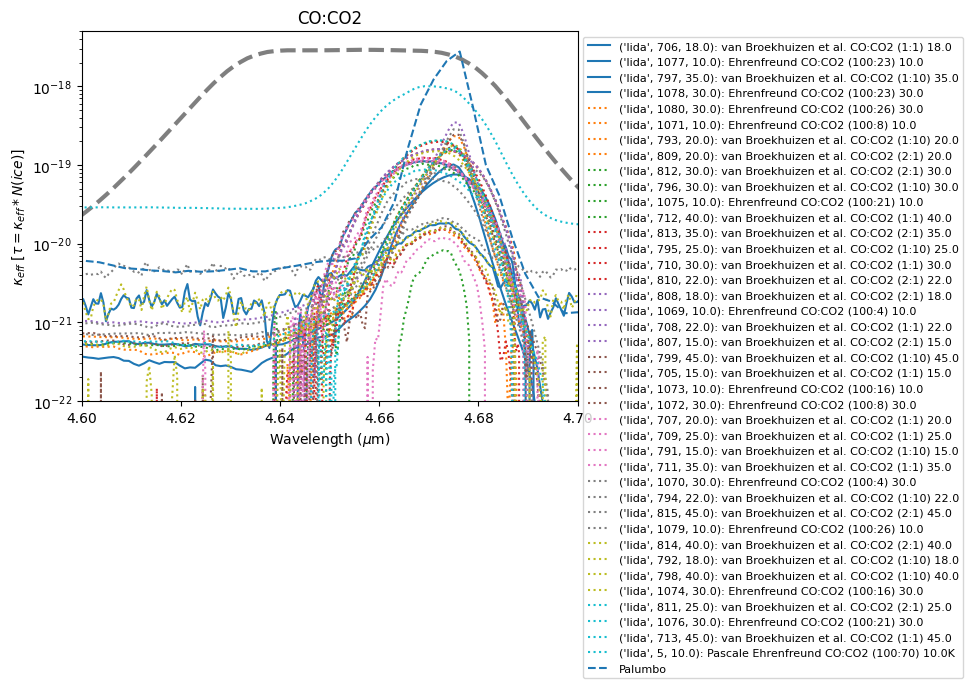

In [17]:
# CO - CO2 mixes
for ii, (key, tb) in enumerate(cotbs.items()):
    #if key in (('ocdb', 64), ('ocdb', 63)):
        # bad - temporary
        #continue

    if 'CO:CO2' in tb.meta['composition'] and key[2] < 50:

        try:
            molwt = u.Quantity(composition_to_molweight(tb.meta['composition']), u.Da)
        except Exception as ex:
            molwt = u.Quantity(composition_to_molweight(tb.meta['compound_name']), u.Da)
        
        kk = tb['k₁'] if 'k₁' in tb.colnames else tb['k']
        opacity = ((kk.quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (molwt)))).to(u.cm**2)
        pl.plot(tb['Wavelength'], 
                opacity,
                label=f'{key}: {tb.meta["author"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                        if 'author' in tb.meta else
                      f'{key}: {tb.meta["index"]} {tb.meta["molecule"]} {tb.meta["ratio"]} {tb.meta["temperature"]}',
                linestyle='-' if ii<10 else ':')
pl.plot(palumbo['Wavelength'],
        (palumbo['k']* palumbo['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da))).to(u.cm**2),
        linestyle='--',
        label='Palumbo')

_, ymax = pl.ylim()
xarr = wavelength_table_466['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_466['Transmission']/wavelength_table_466['Transmission'].max() * ymax,
        color='k', linewidth=3, alpha=0.5, zorder=-5)

pl.semilogy();
pl.ylim(1e-22, 5e-18);
pl.title('CO:CO2')

pl.legend(loc='upper left', bbox_to_anchor=(1,1,), fontsize=8);
pl.xlim(4.60, 4.70);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");

## CO at 4.1

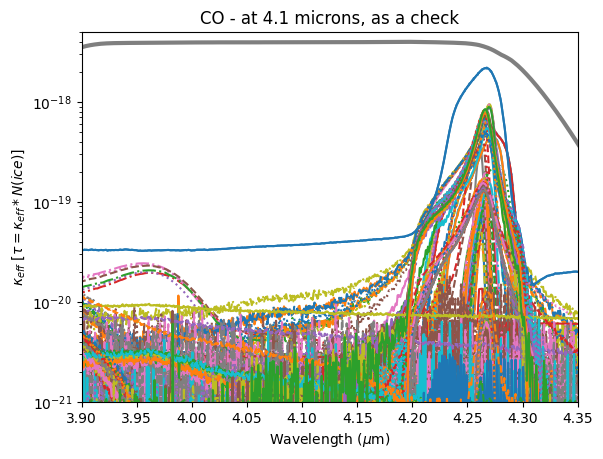

In [18]:
for key, tb in cotbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    if key[2] < 50:
        # limit to T<50
        molwt = u.Quantity(composition_to_molweight(tb.meta['composition']), u.Da)
        pl.plot(tb['Wavelength'], 
                ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (molwt)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}')
pl.plot(palumbo['Wavelength'],
        (palumbo['k'].quantity* palumbo['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da))).to(u.cm**2),
        linestyle='--',
        label='Palumbo')

#pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.5,0.2), fontsize=8);
pl.xlim(3.90, 4.35);
pl.yscale('log')
pl.ylim(1e-21, 5e-18)

_, ymax = pl.ylim()
xarr = wavelength_table_410['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_410['Transmission']/wavelength_table_410['Transmission'].max() * 4e-18,
        color='k', linewidth=3, alpha=0.5, zorder=-5)


pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("CO - at 4.1 microns, as a check");

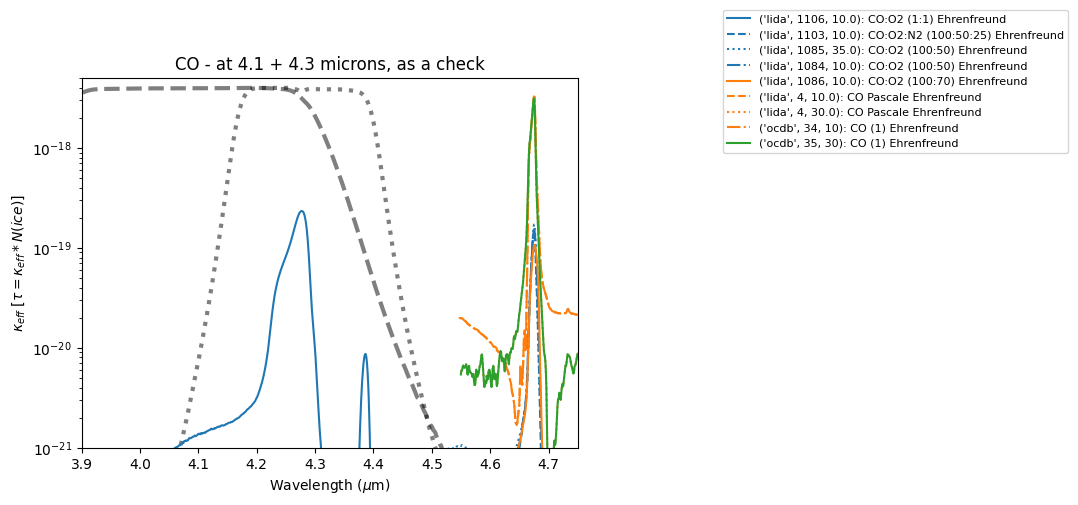

In [19]:
for key, tb in cotbs.items():
    if key[2] < 50:
        if 'Ehrenfr' not in tb.meta['author']:
            # 2025-07-23 trying to hunt down why Ehrenefreund CO is absorbing f430m
            continue
        if 'CO2' in tb.meta['composition']:
            continue
        # limit to T<50
        molwt = u.Quantity(composition_to_molweight(tb.meta['composition']), u.Da)
        pl.plot(tb['Wavelength'], 
                ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (molwt)))).to(u.cm**2),
            label=f'{key}: {tb.meta['composition']} {tb.meta["author"]}')

pl.legend(loc='upper right', bbox_to_anchor=(1,1,1,0.2), fontsize=8);
pl.xlim(3.90, 4.75);
pl.yscale('log')
pl.ylim(1e-21, 5e-18)

_, ymax = pl.ylim()
xarr = wavelength_table_410['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_410['Transmission']/wavelength_table_410['Transmission'].max() * 4e-18,
        color='k', linewidth=3, alpha=0.5, zorder=-5)
xarr = wavelength_table_430['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_430['Transmission']/wavelength_table_430['Transmission'].max() * 4e-18,
        color='k', linewidth=3, alpha=0.5, zorder=-5)


pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("CO - at 4.1 + 4.3 microns, as a check");

In [20]:
tb.colnames

['Wavenumber', 'absorbance', 'Wavelength', 'k']

### CO2

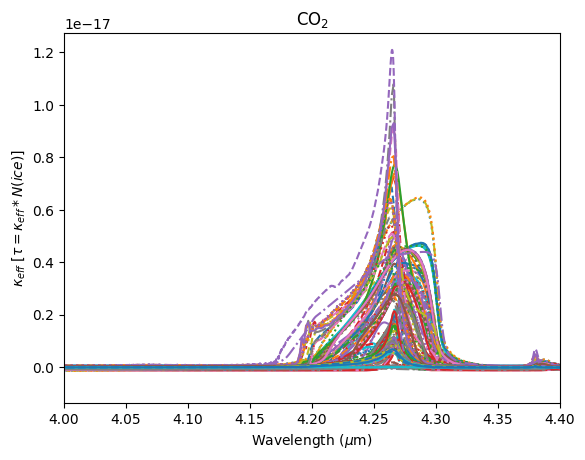

In [21]:
for key, tb in co2tbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    if 'k₁' in tb.colnames:
        tb['k'] = tb['k₁']
    pl.plot(tb['Wavelength'], 
            ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (44*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}')
#pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.2,0));

pl.xlim(4.0, 4.40);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("CO$_2$");

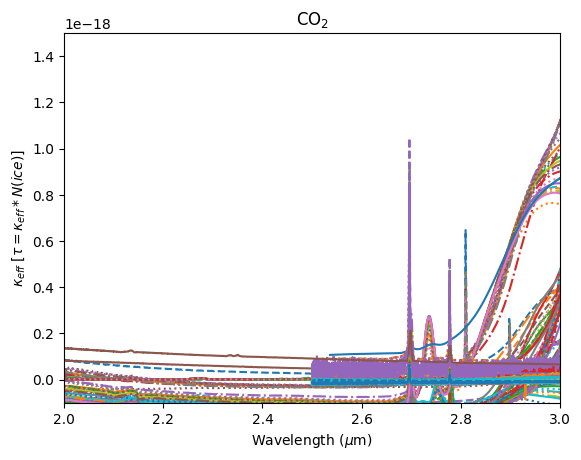

In [22]:
# 2025-07-23: CO2 is absorbing F250M?
for key, tb in co2tbs.items():
    if 'k₁' in tb.colnames:
        tb['k'] = tb['k₁']
    pl.plot(tb['Wavelength'], 
            ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (44*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}')
#pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.2,0));

pl.xlim(2.0, 3.00);
pl.ylim(-1e-19, 1.5e-18);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("CO$_2$");

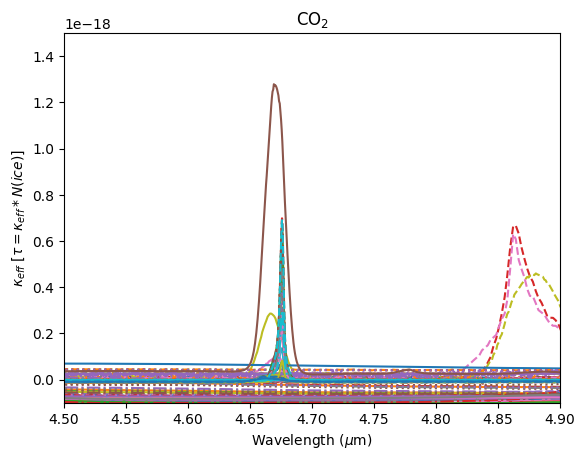

In [23]:
# 2025-07-23: CO2 is absorbing F250M?
for key, tb in co2tbs.items():
    if 'k₁' in tb.colnames:
        tb['k'] = tb['k₁']
    pl.plot(tb['Wavelength'], 
            ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (44*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}')
#pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.2,0));

pl.xlim(4.5, 4.90);
pl.ylim(-1e-19, 1.5e-18);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("CO$_2$");

In [24]:
badkeys = []
for key, tb in co2tbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    if 'k₁' in tb.colnames:
        tb['k'] = tb['k₁']

    if len(tb.meta['composition'].split()) > 1 and tb.meta['composition'].split()[0] == 'CO2' and tb.meta['composition'].split()[1][0] == '(':
        print(tb.meta)
    elif len(tb.meta['composition'].split()) == 1:
        print("BAD: ", key, tb.meta)
        badkeys.append(key)
for key in badkeys:
    print(f"Deleting bad key {key}")
    del co2tbs[key]

{'density': <Quantity 1. g / cm3>, 'reference': 'Hudgins et al. (1993)', 'doi': 'doi https //doi.org/10.1086/191796', 'composition': 'CO2 (1)', 'temperature': '70K', 'ocdb page': 'https //ocdb.smce.nasa.gov/dataset/89', 'author': 'Hudgins', 'molecule': 'CO2', 'database': 'ocdb', 'index': 89}
{'density': <Quantity 1. g / cm3>, 'reference': 'Hudgins et al. (1993)', 'doi': 'doi https //doi.org/10.1086/191796', 'composition': 'CO2 (1)', 'temperature': '10K', 'ocdb page': 'https //ocdb.smce.nasa.gov/dataset/86', 'author': 'Hudgins', 'molecule': 'CO2', 'database': 'ocdb', 'index': 86}
BAD:  ('lida', 3, 50.0) {'comments': ['{"compound_id": 3, "compound_name": "CO2", "author": "Pascale Ehrenfreund", "temperature": "50.0K", "spectrum_type": "n", "spectrum_id": "12", "url": "https://icedb.strw.leidenuniv.nl//spectrum_nval/download/12/12_50.0K.txt", "database": "lida_optcon", "index": 3, "composition": "CO2 1", "filename": "/red/adamginsburg/repos/icemodels/icemodels/data/lida_optcon_3_CO2_50.0K_

In [25]:
import os
from astropy.table import Table
dmag_tbl = dmag_all = Table.read(os.path.join('/orange/adamginsburg/repos/icemodels', 'icemodels', 'data', 'combined_ice_absorption_tables.ecsv'))
dmag_all.add_index('mol_id')
dmag_all.add_index('composition')
dmag_all.add_index('temperature')
dmag_all.add_index('database')
dmag_all.add_index('author')
dmag_tbl.loc['author', 'Hudgins'].loc['composition', 'CO2 (1)'].loc['temperature', 30.0]

molecule,mol_id,molwt,database,author,composition,temperature,density,column,F115W,F150W,F162M,F182M,F187N,F200W,F210M,F212N,F250M,F277W,F300M,F323N,F322W2,F335M,F356W,F360M,F405N,F410M,F430M,F444W,F460M,F466N,F470N,F480M,F560W,F770W,F1000W,F1065C,F1130W,F1140C,F1280W,F1500W,F1550C,F1800W,F2100W,F2300C,F2550W
,,u,,,,K,g / cm3,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
str25,int64,float64,str5,str82,str66,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
co2,87,44.00955,ocdb,Hudgins,CO2 (1),30.0,1.0,1e+17,nan,nan,nan,nan,nan,nan,nan,nan,0.001886547821891682,0.0023678162883626896,0.0019098259188545796,0.002134831674986515,0.0021411359804179853,0.0018820265384089652,0.0019301896554075881,0.0018075974096696257,0.003101466546375775,0.05368462741977176,0.1249149564723524,0.03059681151571425,0.0019828095198093365,0.0018817515222924186,0.0024537614369961602,0.0020906515067586895,0.0019857868847648064,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
co2,87,44.00955,ocdb,Hudgins,CO2 (1),30.0,1.0,1.2067926406393264e+17,nan,nan,nan,nan,nan,nan,nan,nan,0.0022765285963011195,0.00285575193121268,0.0023045786729873896,0.00257619504786355,0.0025831426052462803,0.0022710781916792655,0.002329173402042528,0.0021812557157918633,0.003742729527228761,0.06283834427539503,0.14690907701912082,0.03578857491236853,0.002392721331593961,0.002270762456674902,0.0029611228430024283,0.002522864877832376,0.0023962996101403178,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
co2,87,44.00955,ocdb,Hudgins,CO2 (1),30.0,1.0,1.4563484775012384e+17,nan,nan,nan,nan,nan,nan,nan,nan,0.0027470890486807065,0.0034438234030709225,0.0027808789031418257,0.0031087815868282576,0.0031162093809413705,0.0027405200570065347,0.002810589808827757,0.0026321201162975427,0.004516556533108229,0.073165488252112,0.1719734606329446,0.04164194616125627,0.0028873457442948336,0.0027401625593341805,0.00357337618511977,0.003044402930882484,0.0028916424522993367,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
co2,87,44.00955,ocdb,Hudgins,CO2 (1),30.0,1.0,1.7575106248547965e+17,nan,nan,nan,nan,nan,nan,nan,nan,0.0033148625672101417,0.004152399966354636,0.0033555514883794046,0.003751433863468989,0.003759014042413966,0.00330694756155836,0.0033914522845677197,0.003176127184318034,0.005450340581136359,0.08468383807777258,0.2002452541466475,0.048169078816345134,0.0034841759761867763,0.003306550412014886,0.004312200160230262,0.0036737127539918646,0.0034893298495557445,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
co2,87,44.00955,ocdb,Hudgins,CO2 (1),30.0,1.0,2.1209508879201926e+17,nan,nan,nan,nan,nan,nan,nan,nan,0.003999908546944653,0.005005917097740564,0.004048882994686309,0.004526881035330277,0.004534029897360625,0.003990374846374323,0.0040922779490237815,0.003832495779331424,0.006577130147398691,0.09736794259221782,0.23176620481541654,0.055360722917001226,0.004204311420046736,0.003989945503894532,0.005203750890141023,0.004433044917480089,0.0042104853954469945,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
co2,87,44.00955,ocdb,Hudgins,CO2 (1),30.0,1.0,2.559547922699533e+17,nan,nan,nan,nan,nan,nan,nan,nan,0.004826414621907915,0.006033656688732236,0.004885329515889936,0.005462538026913322,0.005468282314499362,0.004814935745054427,0.00493780588397108,0.004624399732474416,0.007936794487424237,0.11114240542232778,0.26645654329220747,0.06318406569543811,0.005073198210691743,0.00481449036958459,0.0062795852705832544,0.0053492348659816,0.005080582379452636,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
co2,87,44.00955,ocdb,Hudgins,CO2 (1),30.0,1.0,3.088843596477472e+17,nan,nan,nan,nan,nan,nan,nan,nan,0.005823541258534348,0.0072706650843450404,0.005894367242238019,0.0065914678979268615,0.006594250165235849,0.0058097269812691366,0.005957861232946726,0

BAD: ('lida', 3, 50.0) {'comments': ['{"compound_id": 3, "compound_name": "CO2", "author": "Pascale Ehrenfreund", "temperature": "50.0K", "spectrum_type": "n", "spectrum_id": "12", "url": "https://icedb.strw.leidenuniv.nl//spectrum_nval/download/12/12_50.0K.txt", "database": "lida_optcon", "index": 3, "composition": "CO2 1", "filename": "/red/adamginsburg/repos/icemodels/icemodels/data/lida_optcon_3_CO2_50.0K_n.txt"}'], 'compound_id': 3, 'compound_name': 'CO2', 'author': 'Pascale Ehrenfreund', 'temperature': '50.0K', 'spectrum_type': 'n', 'spectrum_id': '12', 'url': 'https://icedb.strw.leidenuniv.nl//spectrum_nval/download/12/12_50.0K.txt', 'database': 'lida_optcon', 'index': 3, 'composition': 'CO2', 'filename': '/red/adamginsburg/repos/icemodels/icemodels/data/lida_optcon_3_CO2_50.0K_n.txt', 'density': <Quantity 1. g / cm3>, 'molecule': 'CO2'}
BAD: ('lida', 3, 10.0) {'comments': ['{"compound_id": 3, "compound_name": "CO2", "author": "Pascale Ehrenfreund", "temperature": "10.0K", "spec

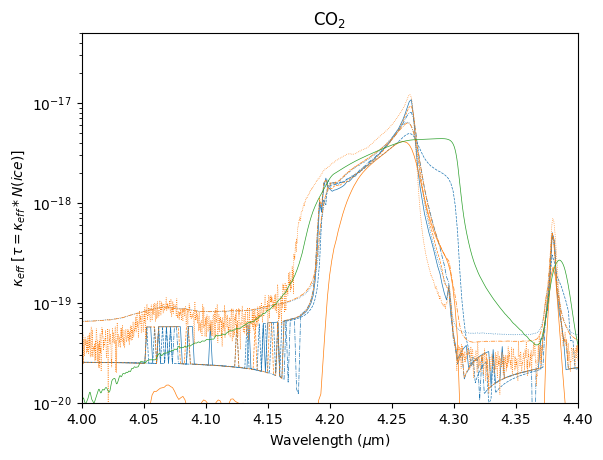

In [26]:
for key, tb in co2tbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    if 'k₁' in tb.colnames:
        tb['k'] = tb['k₁']

    if len(tb.meta['composition'].split()) <= 1:
        print("BAD:", key, tb.meta)
        continue
        
    if tb.meta['composition'].split()[0] == 'CO2' and tb.meta['composition'].split()[1][0] == '(':
        pl.plot(tb['Wavelength'], 
                ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (44*u.Da)))).to(u.cm**2),
                linewidth=0.5,
                label=f'{key}: {tb.meta["author"]}')
#pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.2,0));

pl.xlim(4.0, 4.40);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("CO$_2$");
pl.ylim(1e-20, 5e-17);
pl.yscale('log');

In [27]:
{key:val.meta for key, val in h2otbs.items() if val.meta['author'] == 'Mastrapa'}

{('ocdb', 255, 100): {'density': <Quantity 1. g / cm3>,
  'reference': 'Mastrapa et al. (2009)',
  'doi': 'doi doi 10.1088/0004-637X/701/2/1347',
  'composition': 'H2O (1)',
  'temperature': '100K',
  'ocdb page': 'https //ocdb.smce.nasa.gov/dataset/255',
  'author': 'Mastrapa',
  'molecule': 'H2O',
  'database': 'ocdb',
  'index': 255},
 ('ocdb', 258, 130): {'density': <Quantity 1. g / cm3>,
  'reference': 'Mastrapa et al. (2009)',
  'doi': 'doi doi 10.1088/0004-637X/701/2/1347',
  'composition': 'H2O (1)',
  'temperature': '130K',
  'ocdb page': 'https //ocdb.smce.nasa.gov/dataset/258',
  'author': 'Mastrapa',
  'molecule': 'H2O',
  'database': 'ocdb',
  'index': 258},
 ('lida', 254, 90.0): {'density': <Quantity 1. g / cm3>,
  'reference': 'Mastrapa et al. (2009)',
  'doi': 'doi doi 10.1088/0004-637X/701/2/1347',
  'composition': 'H2O (1)',
  'temperature': '90K',
  'ocdb page': 'https //ocdb.smce.nasa.gov/dataset/254',
  'author': 'Mastrapa',
  'molecule': 'H2O',
  'database': 'ocdb

### H2O

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/astropy/units/equivalencies.py:167: RuntimeWarning: divide by zero encountered in divide
  (si.m, inv_m_spec, lambda x: 1.0 / x),


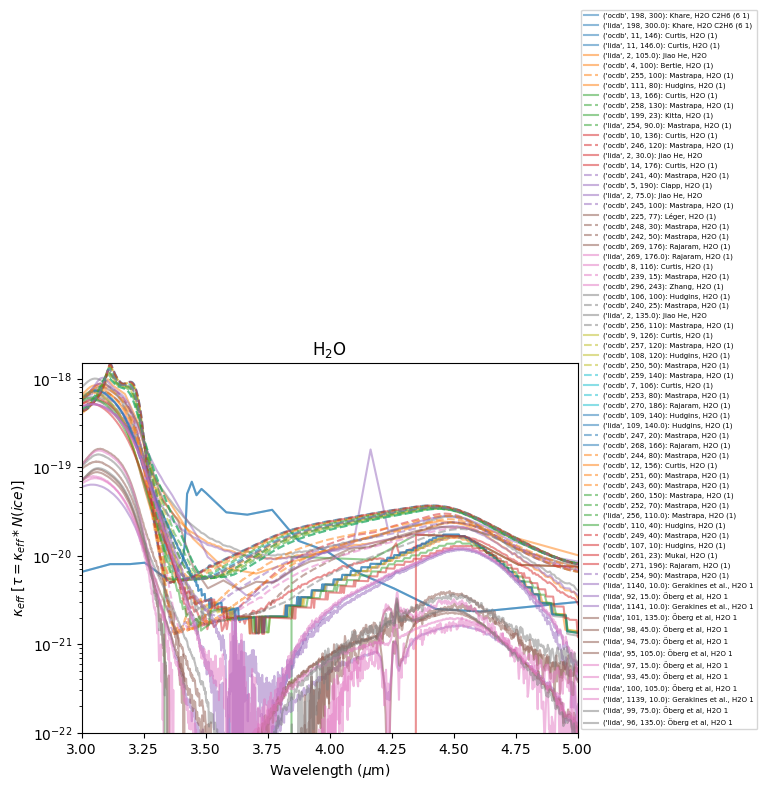

In [28]:
for key, tb in list(h2otbs.items()):
    if any(x in tb.meta['composition'] for x in ('CO', 'OCS', 'NH3', 'CH4', 'CH3OH', 'C18O' '18O2', 'H2O:')):
        continue
    if 'k₁' in tb.colnames:
        tb['k'] = tb['k₁']
    pl.plot(tb['Wavelength'], 
            ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (18*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}, {tb.meta["composition"]}',
            alpha=0.5,
            linestyle='--' if 'Mastrapa' in tb.meta['author'] else '-',
           )
pl.legend(loc='lower left', fontsize=5, bbox_to_anchor=(1,0,0,0));
pl.xlim(3.0, 5.00);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("H$_2$O");
pl.ylim(1e-22, 1.5e-18);
pl.gca().set_yscale('log');

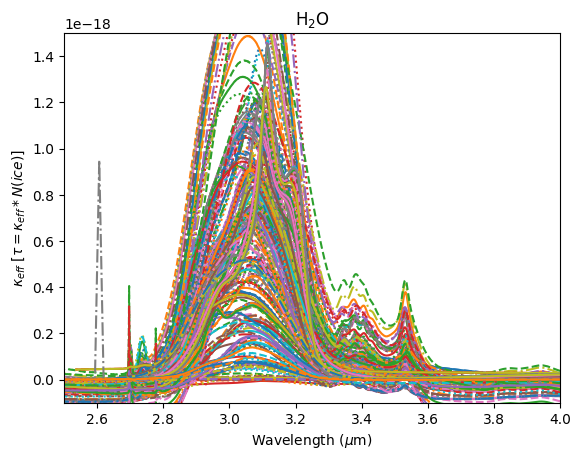

In [29]:
for key, tb in h2otbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    if 'k₁' in tb.colnames:
        tb['k'] = tb['k₁']
    pl.plot(tb['Wavelength'], 
            ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (18*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}, {tb.meta["composition"]}')
#pl.legend(loc='best', fontsize=5);
pl.xlim(2.50, 4.00);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("H$_2$O");
pl.ylim(-1e-19, 1.5e-18);

IndexError: list index out of range

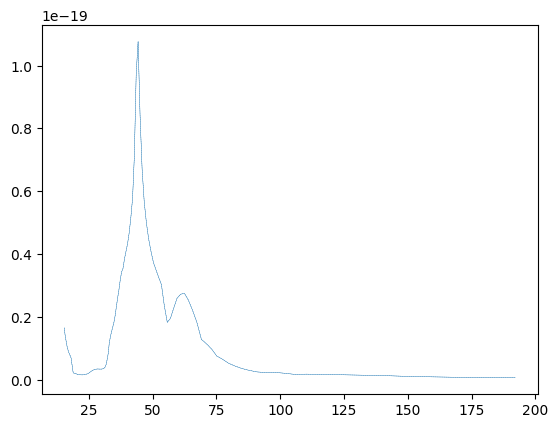

In [30]:
for key, tb in h2otbs.items():
    if tb.meta['composition'].split()[0] == 'H2O' and tb.meta['composition'].split()[1][0] == '(':
        if 'k₁' in tb.colnames:
            tb['k'] = tb['k₁']
        pl.plot(tb['Wavelength'], 
                ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (18*u.Da)))).to(u.cm**2),
                label=f'{key}: {tb.meta["author"]}, {tb.meta["composition"]}',
                linewidth=0.25
               )
pl.legend(loc='lower left', fontsize=5, bbox_to_anchor=(1,0,0,0));
pl.xlim(2.50, 4.00);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("H$_2$O");
pl.ylim(5e-22, 1.5e-18);
pl.axhline(2e-20)
pl.axvline(3.4, linestyle='--', zorder=-10, color='k', alpha=0.5, linewidth=0.5)
pl.yscale('log')

In [ ]:
for key, tb in h2otbs.items():
    if (tb.meta['composition'].split()[0] == 'H2O' and "CO2" in tb.meta['composition']) or (
        tb.meta['composition'].split()[0] == 'H2O' and tb.meta['author'] == 'Mastrapa'): 
        if 'k₁' in tb.colnames:
            tb['k'] = tb['k₁']
        pl.plot(tb['Wavelength'], 
                ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (18*u.Da)))).to(u.cm**2),
                label=f'{key}: {tb.meta["author"]}, {tb.meta["composition"]}',
                linewidth=0.25
               )
pl.legend(loc='lower left', fontsize=5, bbox_to_anchor=(1,0,0,0));
pl.xlim(2.50, 4.90);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("H$_2$O");
pl.ylim(5e-22, 1.5e-18);
pl.axhline(2e-20)
pl.axvline(3.4, linestyle='--', zorder=-10, color='k', alpha=0.5, linewidth=0.5)
pl.yscale('log')

In [ ]:
for key, tb in h2otbs.items():
    if tb.meta['composition'].split()[0] == 'H2O' and tb.meta['composition'].split()[1][0] == '(':
        print(tb.meta)

### Which H2O tables have significant absorption at 3.5 microns?

In [ ]:
for key, tb in h2otbs.items():
    if tb.meta['composition'].split()[0] == 'H2O' and tb.meta['composition'].split()[1][0] == '(':
        if 'k₁' in tb.colnames:
            tb['k'] = tb['k₁']
        ind = np.argmin(np.abs(tb['Wavelength'] - 3.4*u.um))
        opac = ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (18*u.Da)))).to(u.cm**2)
        if opac[ind] > 2e-20*u.cm**2 and (tb['Wavelength'].quantity.min() < 3.4*u.um) and ((tb['Wavelength'].quantity.max() > 3.4*u.um)):
            print(key)

In [ ]:
h2otbs[('ocdb', 225, 77)].meta

In [ ]:
h2otbs[('ocdb', 5, 190)].meta

In [ ]:
for key, tb in h2otbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    if 'k₁' in tb.colnames:
        tb['k'] = tb['k₁']
    pl.plot(tb['Wavelength'], 
            ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (18*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}, {tb.meta["composition"]}')
#pl.legend(loc='best', fontsize=5);
pl.xlim(1.20, 4.90);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("H$_2$O");
pl.ylim(-1e-19, 1.5e-18);

In [ ]:
tb.meta

In [ ]:
for key, tb in h2otbs.items():
    if 'OCS' in tb.meta['composition'] or 'CO' in tb.meta['composition']:
        continue
    if 'k₁' in tb.colnames:
        tb['k'] = tb['k₁']
    pl.plot(tb['Wavelength'], 
            ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (18*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}, {tb.meta["composition"]}')
#pl.legend(loc='lower left', fontsize=5, bbox_to_anchor=(1,1,0,0));
pl.xlim(4.5, 4.8);

pl.ylim(-1e-20, 0.4e-19);

_, ymax = pl.ylim()
xarr = wavelength_table_466['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_466['Transmission']/wavelength_table_466['Transmission'].max() * ymax,
        color='k', linewidth=3, alpha=0.5, zorder=-5)


pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("H$_2$O");

In [ ]:
for key, tb in h2otbs.items():
    if 'OCS' in tb.meta['composition'] or 'CO' in tb.meta['composition']:
        continue
    if 'k₁' in tb.colnames:
        tb['k'] = tb['k₁']
    pl.plot(tb['Wavelength'], 
            ((tb['k'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (18*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}, {tb.meta["composition"]}')
#pl.legend(loc='lower left', fontsize=5, bbox_to_anchor=(1,1,0,0));
pl.xlim(3.8, 4.4);

pl.ylim(-1e-20, 0.4e-19);

_, ymax = pl.ylim()
xarr = wavelength_table_410['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_410['Transmission']/wavelength_table_410['Transmission'].max() * ymax,
        color='k', linewidth=3, alpha=0.5, zorder=-5)


pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("H$_2$O");

# Make absorbance -> N tables

In [ ]:
import icemodels
imp.reload(icemodels.core)
imp.reload(icemodels)
from icemodels import absorbed_spectrum, absorbed_spectrum_Gaussians, convsum, fluxes_in_filters, load_molecule, load_molecule_ocdb, atmo_model, molecule_data
from icemodels.core import composition_to_molweight

In [ ]:
from astroquery.svo_fps import SvoFps

In [ ]:
jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')

In [ ]:
#filterid = 'JWST/NIRCam.F466N'
#xarr = np.linspace(filter_data.loc[filterid]['WavelengthMin'] * u.AA,
#                   filter_data.loc[filterid]['WavelengthMax'] * u.AA,
#                   1000)
xarr = np.linspace(3.1*u.um, 4.9*u.um, 10000)
phx4000 = atmo_model(4000, xarr=xarr)

In [ ]:
tb.meta

In [ ]:
from astropy.table import Table
import time

## Calculate dmags

In [ ]:
molecule_data

In [ ]:
%pip install molmass

In [ ]:
import re
from molmass import Formula
compstr =  'CO:CH3OH:CH3OCH3 (20:20:1)'
mols, comps = compstr.split(" (")
print(mols, re.split("[: ]", mols))
print(comps)
comps = map(int, comps.strip(")").split(":"))
molvals = [Formula(mol).mass for mol in re.split("[: ]", mols)]

## column vs dmag plots

In [ ]:
dmag_tbl = Table.read('/orange/adamginsburg/jwst/brick/tables/combined_ice_absorption_tables.ecsv')

In [ ]:
dmag_tbl = Table.read(f'{basepath}/tables/CO_ice_absorption_tables.ecsv')

dmag_tbl.add_index('database')
dmag_tbl.add_index('mol_id')
dmag_tbl.add_index('temperature')

fig = pl.figure(figsize=(12,12))
for database in set(dmag_tbl['database']):
    db_dmag_tbl = dmag_tbl.loc[('database', database)]
    for ii, mol_id in enumerate(set(db_dmag_tbl['mol_id'])):
        row = dmag_tbl.loc[('database', database)].loc[('mol_id', mol_id)]
        temp = row['temperature'][0]
        row = dmag_tbl.loc[('database', database)].loc[('mol_id', mol_id)].loc[('temperature', temp)][0]
        temp = float(temp.strip('K'))
        cols = row['column']
        filtername = 'F466N'
        #tb = cotbs[(database, mol_id, temp)]
        pl.semilogy(row[filtername], cols,
                label=f'{mol_id}: {row["author"]} {row["composition"]} {row["temperature"]}', linestyle='-' if ii<10 else ':')
        pl.xlim(0,3);
        pl.ylim(1e16, 1e22);
        pl.title(filtername)
        pl.xlabel(f"dmag{filtername}")
        pl.ylabel(f"N(CO)")
pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.4,0), fontsize=8);

In [ ]:
Table.read(f'{basepath}/tables/H2O_ice_absorption_tables.ecsv')[:3]

In [ ]:
dmag_tbl = Table.read(f'{basepath}/tables/H2O_ice_absorption_tables.ecsv')

dmag_tbl.add_index('database')
dmag_tbl.add_index('mol_id')
dmag_tbl.add_index('temperature')

fig = pl.figure(figsize=(12,12))
for database in set(dmag_tbl['database']):
    db_dmag_tbl = dmag_tbl.loc[('database', database)]
    for ii, mol_id in enumerate(set(db_dmag_tbl['mol_id'])):
        row = dmag_tbl.loc[('database', database)].loc[('mol_id', mol_id)]
        temp = row['temperature'][0]
        row = dmag_tbl.loc[('database', database)].loc[('mol_id', mol_id)].loc[('temperature', temp)]
        temp = int(float(temp.strip('K')))
        cols = row['column']
        filtername = 'F466N'
        #tb = h2otbs[(database, mol_id, temp)]
        
        pl.semilogy(row[filtername], cols,
                label=f'{mol_id}: {row["author"]} {row["composition"]} {row["temperature"]}', linestyle='-' if ii<10 else ':')
        pl.xlim(0,3);
        pl.ylim(1e16, 1e22);
        pl.title(filtername)
        pl.xlabel(f"dmag{filtername}")
        pl.ylabel(f"N(H$_2$O)")
#pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.4,0), fontsize=8);


In [ ]:
dmag_tbl = Table.read(f'{basepath}/tables/H2O_ice_absorption_tables.ecsv')

dmag_tbl.add_index('database')
dmag_tbl.add_index('mol_id')
dmag_tbl.add_index('temperature')

fig = pl.figure(figsize=(12,12))
for database in set(dmag_tbl['database']):
    db_dmag_tbl = dmag_tbl.loc[('database', database)]
    for ii, mol_id in enumerate(set(db_dmag_tbl['mol_id'])):
        row = dmag_tbl.loc[('database', database)].loc[('mol_id', mol_id)]
        temp = row['temperature'][0]
        row = dmag_tbl.loc[('database', database)].loc[('mol_id', mol_id)].loc[('temperature', temp)]
        temp = int(float(temp.strip('K')))
        cols = row['column']
        filtername = 'F410M'
        #tb = h2otbs[(database, mol_id, temp)]
        pl.semilogy(row[filtername], cols,
                label=f'{mol_id}: {row["author"]} {row["composition"]} {row["temperature"]}', linestyle='-' if ii<10 else ':')
        pl.xlim(0,3);
        pl.ylim(1e16, 1e22);
        pl.title(filtername)
        pl.xlabel(f"dmag{filtername}")
        pl.ylabel(f"N(H$_2$O)")
#pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.4,0), fontsize=8);


# Gerakines - direct from paper

In [ ]:
import icemodels
imp.reload(icemodels.core)
imp.reload(icemodels)
from icemodels.core import absorbed_spectrum, absorbed_spectrum_Gaussians, convsum, fluxes_in_filters, load_molecule, load_molecule_ocdb, atmo_model, molecule_data, retrieve_gerakines_co

In [ ]:
gerakines = retrieve_gerakines_co()

In [ ]:
wavelength = gerakines['Wavelength']
pl.semilogy(wavelength, gerakines['k'])
pl.xlim(4.4, 5.0);
pl.ylim(1e-4, 3);
pl.xlabel("Wavelength [$\\mu$m]")
pl.ylabel("k");


_, ymax = pl.ylim()
xarr = wavelength_table_466['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_466['Transmission']/wavelength_table_466['Transmission'].max(),
        color='k', linewidth=3, alpha=0.5, zorder=-5, linestyle='--');


In [ ]:
wavelength = gerakines['Wavelength']
pl.semilogy(wavelength, gerakines['k'])
pl.xlim(4.4, 5.0);
pl.ylim(1e-4, 3);
pl.xlabel("Wavelength [$\\mu$m]")
pl.ylabel("k");


_, ymax = pl.ylim()
xarr = wavelength_table_466['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_466['Transmission']/wavelength_table_466['Transmission'].max(),
        color='k', linewidth=3, alpha=0.5, zorder=-5, linestyle='--');
pl.xlim(4.6, 4.7);
pl.ylim(1e-3,3);

# H2O + CO mix

Based on McClure, H2O : CO ~ 5

we'll use 25K Mastrapa water plus Gerakines CO



In [ ]:
import icemodels
imp.reload(icemodels.core)
imp.reload(icemodels)
from icemodels import absorbed_spectrum, absorbed_spectrum_Gaussians, convsum, fluxes_in_filters, load_molecule, load_molecule_ocdb, atmo_model, molecule_data
from icemodels.core import composition_to_molweight

In [ ]:
water_mastrapa = load_molecule_ocdb('242_H2O_(1)_50K_Mastrapa.txt'.lower())#h2otbs[('ocdb', 242, 25)]
co_gerakines = gerakines
grid = co_gerakines['Wavelength']
inds = np.argsort(water_mastrapa['Wavelength'])
co_plus_water_k = gerakines['k'] + np.interp(grid, water_mastrapa['Wavelength'][inds], 3*water_mastrapa['k'][inds],)
co_plus_water_table = Table({'Wavelength': grid, 'k': co_plus_water_k})
co_plus_water_table.meta['composition'] = 'H2O:CO (5:1)'
co_plus_water_table.meta['density'] = 1*u.g/u.cm**3
pl.plot(grid, co_plus_water_k, label='CO + H$_2$O 1:3')
pl.plot(grid, gerakines['k'], label='CO @ 25K [Gerakines 2023]')
pl.plot(water_mastrapa['Wavelength'], water_mastrapa['k'], label='H$_2$O @ 25K [Mastrapa 2009]')
pl.legend(loc='best')
pl.ylabel('k')
pl.xlabel(r'Wavelength [$\mu$m]')
pl.axis((4.0,5.0,1e-3, 3));
pl.gca().set_yscale('log');

In [ ]:
molwt

In [ ]:
(18 * 5 + 28 * 1) / 6

In [ ]:
import molmass
xarr = phx4000['nu'].quantity.to(u.um, u.spectral())
cols = np.geomspace(1e15, 1e22, 25)

mol = 'COplusH2O'
tbs = {('COplusH2O', 'made_up'): co_plus_water_table}

dmag_rows = []

for key, consts in tbs.items():

    dmags410 = []
    dmags466 = []
    dmags444 = []
    dmags356 = []
    dmags405 = []

    molecule = mol.lower()
    molwt = u.Quantity(composition_to_molweight(consts.meta['composition']), u.Da)

    tt0 = time.time()
    print(molecule, key, end=":  ")
    #print(f"  column,   mag410,  mag410*,  mag466n, mag466n*, dmag410, dmag466")
    for col in cols:
        t0 = time.time()
        spec = absorbed_spectrum(col*u.cm**-2, consts, molecular_weight=molwt,
                                  spectrum=phx4000['fnu'].quantity,
                                  xarr=xarr,
                                 )
        t1 = time.time()
        cmd_x = ('JWST/NIRCam.F410M', 'JWST/NIRCam.F466N', 'JWST/NIRCam.F356W', 'JWST/NIRCam.F444W',  'JWST/NIRCam.F405N')
        flxd_ref = fluxes_in_filters(xarr, phx4000['fnu'].quantity, filterids=cmd_x)
        t2 = time.time()
        flxd = fluxes_in_filters(xarr, spec, filterids=cmd_x)
        t3 = time.time()
        mags_x_star = (-2.5*np.log10(flxd_ref[cmd_x[0]] / u.Quantity(jfilts.loc[cmd_x[0]]['ZeroPoint'], u.Jy)),
                       -2.5*np.log10(flxd_ref[cmd_x[1]] / u.Quantity(jfilts.loc[cmd_x[1]]['ZeroPoint'], u.Jy)),
                       -2.5*np.log10(flxd_ref[cmd_x[2]] / u.Quantity(jfilts.loc[cmd_x[2]]['ZeroPoint'], u.Jy)),
                       -2.5*np.log10(flxd_ref[cmd_x[3]] / u.Quantity(jfilts.loc[cmd_x[3]]['ZeroPoint'], u.Jy)),
                       -2.5*np.log10(flxd_ref[cmd_x[4]] / u.Quantity(jfilts.loc[cmd_x[4]]['ZeroPoint'], u.Jy)),
                      )
        mags_x = (-2.5*np.log10(flxd[cmd_x[0]] / u.Quantity(jfilts.loc[cmd_x[0]]['ZeroPoint'], u.Jy)),
                  -2.5*np.log10(flxd[cmd_x[1]] / u.Quantity(jfilts.loc[cmd_x[1]]['ZeroPoint'], u.Jy)),
                  -2.5*np.log10(flxd[cmd_x[2]] / u.Quantity(jfilts.loc[cmd_x[2]]['ZeroPoint'], u.Jy)),
                  -2.5*np.log10(flxd[cmd_x[3]] / u.Quantity(jfilts.loc[cmd_x[3]]['ZeroPoint'], u.Jy)),
                  -2.5*np.log10(flxd[cmd_x[4]] / u.Quantity(jfilts.loc[cmd_x[4]]['ZeroPoint'], u.Jy)),
                 )
        dmags405.append(mags_x[4]-mags_x_star[4])
        dmags444.append(mags_x[3]-mags_x_star[3])
        dmags356.append(mags_x[2]-mags_x_star[2])
        dmags466.append(mags_x[1]-mags_x_star[1])
        dmags410.append(mags_x[0]-mags_x_star[0])
        # why would f410m change at all?
        #print(f"{col:8.1g}, {mags_x[0]:8.1f}, {mags_x_star[0]:8.1f}, {mags_x[1]:8.1f}, {mags_x_star[1]:8.1f}, {dmags410[-1]:8.1f}, {dmags466[-1]:8.1f}")
        try:
            database, mol_id = key
        except TypeError:
            mol_id = key
            database = 'ocdb'
        dmag_rows.append({'molecule': molecule, 'mol_id': mol_id, 'database': database, 'column': col, 'F356W': dmags356[-1], 'F410M': dmags410[-1],
                          'F444W': dmags444[-1], 'F466N': dmags466[-1], 'F405N': dmags405[-1]})
        t4 = time.time()
        #print(f"col={col:0.1g}; Steps took {t1-t0:0.1g}, {t2-t1:0.1g}, {t3-t2:0.1g}, {t4-t3:0.1g}")
tt1 = time.time()
print(f"Done with {molecule} {key}; dt={tt1-tt0:0.3g}")
dmag_tbl = Table(dmag_rows)
dmag_tbl.write(f'{basepath}/tables/{mol}_ice_absorption_tables.ecsv', overwrite=True)
dmag_tbl.add_index('database')
dmag_tbl.add_index('mol_id')
dmag_tbl

In [ ]:
pl.semilogy(dmag_tbl['F410M'], dmag_tbl['column'], label='F410M')
pl.semilogy(dmag_tbl['F466N'], dmag_tbl['column'], label='F466N')
pl.semilogy(-(dmag_tbl['F410M']-dmag_tbl['F466N']), dmag_tbl['column'], label='-(F410M-F466N)')
pl.legend(loc='lower right');
pl.xlim(0,5);
pl.ylim(1e17,2e20);

In [ ]:
sel = dmag_tbl['column'] < 1e20
pl.plot(dmag_tbl['F410M'][sel] - dmag_tbl['F466N'][sel], dmag_tbl['F356W'][sel] - dmag_tbl['F444W'][sel])

# Script version

In [ ]:
import importlib as imp
import icemodels.core
imp.reload(icemodels.core)
from icemodels.core import composition_to_molweight

In [ ]:
# takes 30 minutes...
# %run -i /orange/adamginsburg/jwst/brick/analysis/co_ice_absorbance_models.py

In [ ]:
ls -lh $basepath/tables/*ecsv

In [ ]:
dmag_h2o = Table.read(f'{basepath}/tables/H2O_ice_absorption_tables.ecsv')
dmag_co2 = Table.read(f'{basepath}/tables/CO2_ice_absorption_tables.ecsv')
dmag_co = Table.read(f'{basepath}/tables/CO_ice_absorption_tables.ecsv')
dmag_mine = Table.read(f'{basepath}/tables/H2O+CO_ice_absorption_tables.ecsv')

In [ ]:
dmag_mine.add_index('mol_id')
dmag_h2o.add_index('composition')
dmag_h2o.add_index('temperature')

In [ ]:
dcol = 2
for mol_id in np.unique(dmag_mine['mol_id']):
    tb = dmag_mine.loc[mol_id]
    comp = np.unique(tb['composition'])[0]
    sel = tb['column'] < 5e19
    L, = pl.plot(tb['F410M'][sel] - tb['F466N'][sel], tb['F356W'][sel] - tb['F444W'][sel], label=comp, )
    pl.scatter(tb['F410M'][sel][::dcol] - tb['F466N'][sel][::dcol], tb['F356W'][sel][::dcol] - tb['F444W'][sel][::dcol],
               s=(np.log10(tb['column'][sel][::dcol])-14.9)*20, c=L.get_color())

comp = 'H2O (1)'
tb = dmag_h2o.loc[comp].loc['temperature', '25K']
comp = np.unique(tb['composition'])[0]
sel = tb['column'] < 5e20
L, = pl.plot(tb['F410M'][sel] - tb['F466N'][sel], tb['F356W'][sel] - tb['F444W'][sel], label=comp, )
pl.scatter(tb['F410M'][sel][::dcol] - tb['F466N'][sel][::dcol], tb['F356W'][sel][::dcol] - tb['F444W'][sel][::dcol],
           s=(np.log10(tb['column'][sel][::dcol])-14.9)*20, c=L.get_color())

#pl.legend(loc='best');
pl.xlabel("410 - 466")
pl.ylabel("356 - 444");

In [ ]:
imp.reload(icemodels.core)
from icemodels.core import parse_molscomps

In [ ]:
#pl.figure(figsize=(12,12))

import re
for ii, mol_id in enumerate(np.unique(dmag_mine['mol_id'])):
    tb = dmag_mine.loc[mol_id]
    comp = np.unique(tb['composition'])[0]
    molwt = u.Quantity(composition_to_molweight(comp), u.Da)
    mols, comps = parse_molscomps(comp)
    #print(co_massfrac, molwt, comps)
    #pl.subplot(3, 3, ii+1)
    #pl.semilogy(tb['F410M'], tb['column'], label='F410M')
    #pl.semilogy(tb['F466N'], tb['column'], label='F466N')
    #pl.semilogy(-(tb['F410M']-tb['F466N']), tb['column'] * molwt * co_massfrac / (28*u.Da), label=comp)
    pl.semilogy(-(tb['F410M']-tb['F466N']), tb['column'], label=comp + "TODO: should this be scaled by molwt?")
    #pl.title(comp)
    pl.ylim(1e16,5e20);
pl.grid()

dmag_h2o.add_index('composition')
dmag_h2o.add_index('temperature')
comp = 'H2O CH3OH CO NH3 (100 10 1 1)'
tb = dmag_h2o.loc[comp].loc['temperature', '40K']
molwt = composition_to_molweight(comp)
print(comp, molwt, 1/112.)
pl.semilogy(-(tb['F410M']-tb['F466N']), tb['column'] * molwt * 1/112 / (28*u.Da), label=comp, linestyle='--')
# comp = 'H2O (1)'
# tb = dmag_h2o.loc[comp].loc['temperature', '25K']
# pl.semilogy(-(tb['F410M']-tb['F466N']), tb['column'], label=comp, linestyle='--')
pl.xlim(0,2);
pl.ylabel('N(CO)')
pl.xlabel('$\\Delta$[F410M - F466N]')

pl.legend(loc='lower left', bbox_to_anchor=(1,0,0,0), fontsize=8);
pl.tight_layout()

In [ ]:
[x for x in cotbs.keys() if x[1] == 75]

In [ ]:
dmag_co.add_index('mol_id')
dmag_co.loc['mol_id', 75][:1] # there should be a 75 here

In [ ]:
dmag_co.add_index('composition')
dmag_co.add_index('temperature')
dmag_co.loc['composition', 'CO 1'].loc['temperature', '22.0'][:1]

In [ ]:
#pl.figure(figsize=(12,12))

# this existed...
# dmag_co.add_index('composition')
# dmag_co.add_index('temperature')
# comp = 'CO:O2:CO2 (100:11:20)'
# tb = dmag_co.loc[comp].loc['temperature', '10.0']
# pl.semilogy(-(tb['F410M']-tb['F466N']), tb['column'], label=comp, linestyle='--')


dmag_h2o.add_index('composition')
dmag_h2o.add_index('temperature')
comp = 'H2O CH3OH CO NH3 (100 10 1 1)'
tb = dmag_h2o.loc[comp].loc['temperature', '40K']
pl.semilogy(-(tb['F410M']-tb['F466N']), tb['column'], label=comp, linestyle='--')
comp = 'H2O (1)'
tb = dmag_h2o.loc[comp].loc['temperature', '25K']
pl.semilogy(-(tb['F410M']-tb['F466N']), tb['column'], label=comp, linestyle='--')

pl.xlabel("466 - 410")
pl.ylabel("N(molecule)")
pl.xlim(0,3);
pl.legend(loc='lower right');
pl.tight_layout()

In [ ]:
key = ('ocdb', 122, 40)
tb = h2otbs[key]
comp = tb.meta['composition']

if 'k₁' in tb.colnames:
    pl.plot(tb['Wavelength'], 
            ((tb['k₁'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (18*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}, {tb.meta["composition"]}',
            alpha=0.5
           )
else:
    print(f'{key} -> {tb.meta} failed - no k₁')
pl.legend(loc='lower left', fontsize=5, bbox_to_anchor=(1,0,0,0));
pl.xlim(3.0, 5.00);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title(comp);
pl.ylim(1e-22, 1.5e-18);
pl.gca().set_yscale('log');

## Which models have the highest opacity (give the lowest CO column)?

In [ ]:
dmag_co.add_index('column')
col19 = dmag_co.loc['column', 1e19]
col19 = col19[col19['F466N'] > 0]
col19 = col19[(np.char.find(col19['composition'], 'CH3') < 0)]
col19.sort('F466N')
col19

In [ ]:
dmag_co.add_index('column')
col19 = dmag_co.loc['column', 1e19]
#col19 = col19[col19['F466N'] > 0]
col19 = col19[(np.char.find(col19['composition'], 'H2O') >= 0)]
col19.sort('F466N')
col19

In [ ]:
dmag_h2o.add_index('column')
col19 = dmag_h2o.loc['column', 1e19]
col19 = col19[col19['F466N'] > 0]
col19 = col19[(np.char.find(col19['composition'], 'CO:') >= 0) | (np.char.find(col19['composition'], ':CO ') >= 0)]
col19.sort('F466N')
col19

In [ ]:
dmag_co2.add_index('column')
col19 = dmag_co2.loc['column', 1e19]
col19 = col19[col19['F466N'] > 0]
#col19 = col19[(np.char.find(col19['composition'], 'CO:') >= 0) | (np.char.find(col19['composition'], ':CO ') >= 0)]
col19.sort('F466N')
col19

## Elsila CO:H2O 5:1


In [ ]:
[x for x in h2otbs if x[1] == 142]

In [ ]:
def get_tb(key):
    if key[0] == 'ocdb':
        fns = glob.glob(f'{optical_constants_cache_dir}/{key[1]}*{key[2]}*txt')
        for fn in fns:
            try:
                tb = read_ocdb_file(fn)
                return tb
            except:
                continue
    if key[0] == 'lida':
        fns = glob.glob(f'{optical_constants_cache_dir}/{key[1]}*{key[2]}*txt')
        for fn in fns:
            try:
                tb = read_lida_file(fn)
                return tb
            except:
                continue

In [ ]:
#pl.plot(tb['Wavelength'], tb['k'])
# bad:  (h2otbs, ('lida', 142, 10)),
for tbs, key in [(cotbs, ('ocdb', 41, 12)),
                 (h2otbs, ('ocdb', 39, 12)), # Elsila H2O:CO 20:1
                 (cotbs, ('ocdb', 85, 10)),
                 (cotbs, ('ocdb', 36, 10)), # Ehrenfreund CO:CO2
                 (h2otbs, ('lida', 143, 10)),
                 #(mymix_tables, ('COplusH2OplusCO2', 6, 25)),
                 (h2otbs, ('lida', 154, 20))]:
    try:
        tb = tbs[key]
    except:
        tb = get_tb(key)

    molwt = u.Quantity(composition_to_molweight(tb.meta['composition']), u.Da)
    
    kk = tb['k₁'] if 'k₁' in tb.colnames else tb['k']
    opacity = ((kk.quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (molwt)))).to(u.cm**2)
    pl.plot(tb['Wavelength'], 
            opacity,
            label=f'{key}: {tb.meta["author"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                    if 'author' in tb.meta else
                  f'{key}: {tb.meta["index"]} {tb.meta["molecule"]} {tb.meta["ratio"]} {tb.meta["temperature"]}',
            linestyle='-' if ii<10 else ':')
pl.plot(palumbo['Wavelength'],
        (palumbo['k']* palumbo['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da))).to(u.cm**2),
        linestyle='--',
        label='Palumbo')

_, ymax = pl.ylim()
xarr = wavelength_table_466['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_466['Transmission']/wavelength_table_466['Transmission'].max() * ymax,
        color='k', linewidth=3, alpha=0.5, zorder=-5)

pl.semilogy();
pl.ylim(1e-22, 5e-18);

pl.legend(loc='upper left', bbox_to_anchor=(1,0,0.0,0.2,), fontsize=8);
pl.xlim(4.61, 4.70);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");

In [ ]:
import brick2221.analysis
imp.reload(brick2221.analysis)
from brick2221.analysis import co_ice_absorbance_models
#mymix_tables = co_ice_absorbance_models.make_mymix_tables()

### Full 410 + 466

In [ ]:

for tbs, key in [#(cotbs, ('ocdb', 41, 12)),
                 #(h2otbs, ('ocdb', 39, 12)), # Elsila H2O:CO 20:1
                 (cotbs, ('ocdb', 85, 10)), # Hudgins CO
                 (co2tbs, ('ocdb', 86, 10)), # Hudgins CO2
]:
    try:
        tb = tbs[key]
    except:
        tb = get_tb(key)
    
    molwt = u.Quantity(composition_to_molweight(tb.meta['composition']), u.Da)
    
    kk = tb['k₁'] if 'k₁' in tb.colnames else tb['k']
    opacity = ((kk.quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (molwt)))).to(u.cm**2)
    pl.plot(tb['Wavelength'][kk>1e-3], 
            opacity[kk>1e-3],
            label=f'{key}: {tb.meta["author"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                    if 'author' in tb.meta else
                  f'{key}: {tb.meta["index"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                    if 'molecule' not in tb.meta else
                  f'{key}: {tb.meta["index"]} {tb.meta["molecule"]} {tb.meta["ratio"]} {tb.meta["temperature"]}',
            linestyle='-' if ii<10 else ':')

_, ymax = pl.ylim()
xarr = wavelength_table_466['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_466['Transmission']/wavelength_table_466['Transmission'].max() * ymax,
        color='k', linewidth=3, alpha=0.5, zorder=-5)
xarr = wavelength_table_410['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_410['Transmission']/wavelength_table_410['Transmission'].max() * ymax,
        color='k', linewidth=3, alpha=0.5, zorder=-5)


pl.semilogy();
pl.ylim(1e-21, 6e-18);

pl.legend(loc='best')
pl.xlim(3.71, 4.75);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("Hudgins 1993 CO & CO$_2$ opacities have a limited range of validity");


In [ ]:
read_ocdb_file('/orange/adamginsburg/repos/icemodels/icemodels/data/55_CO2_(1)_8K_Gerakines.txt').meta

In [ ]:
#pl.plot(tb['Wavelength'], tb['k'])
# bad:  (h2otbs, ('lida', 142, 10)),
for tbs, key in [#(cotbs, ('ocdb', 41, 12)),
                 #(h2otbs, ('ocdb', 39, 12)), # Elsila H2O:CO 20:1
                 #(cotbs, ('ocdb', 85, 10)), # Hudgins CO
                 #(co2tbs, ('ocdb', 86, 10)), # Hudgins CO2
                 (cotbs, ('ocdb', 36, 10)), # Ehrenfreund CO:CO2
                 (h2otbs, ('lida', 143, 10)),
                 #(mymix_tables, ('COplusH2OplusCO2', 8, 25)),
                 # (h2otbs, ('lida', 154, 20)), # Ehrenfreund, an order of magnitude too low for some reason?
                 # (h2otbs, ('lida', 143, 10)), LOL no
                 (co2tbs, ('lida', 140, 10)),
                 (co2tbs, ('ocdb', 55, 8)),
                 (h2otbs, ('ocdb', 242, 50)), # mastrapa 25 
                 (h2otbs, ('ocdb', 240, 25)), # mastrapa 25 
                 ('', ('ocdb', 267, 15)), # palumbo CO 15
                 ('', ('lida', 158, 12)), # novozamsky OCN-
                 #(h2otbs, ('ocdb', 261, 140)), # mastrapa 140
]:
    try:
        tb = tbs[key]
    except:
        tb = get_tb(key)
    

    print(key)
    print(key, tb.meta['composition'])
    molwt = u.Quantity(composition_to_molweight(tb.meta['composition']), u.Da)
    
    kk = tb['k₁'] if 'k₁' in tb.colnames else tb['k']
    opacity = ((kk.quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (molwt)))).to(u.cm**2)
    pl.plot(tb['Wavelength'], 
            opacity,
            label=f'{key}: {tb.meta["author"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                    if 'author' in tb.meta else
                  f'{key}: {tb.meta["index"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                    if 'molecule' not in tb.meta else
                  f'{key}: {tb.meta["index"]} {tb.meta["molecule"]} {tb.meta["ratio"]} {tb.meta["temperature"]}',
            linestyle='-' if ii<10 else ':')

pl.plot(palumbo['Wavelength'],
        (palumbo['k']* palumbo['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da))).to(u.cm**2),
        linestyle='--',
        label='Palumbo')

_, ymax = pl.ylim()
xarr = wavelength_table_466['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_466['Transmission']/wavelength_table_466['Transmission'].max() * ymax,
        color='k', linewidth=3, alpha=0.5, zorder=-5)
xarr = wavelength_table_410['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_410['Transmission']/wavelength_table_410['Transmission'].max() * ymax,
        color='k', linewidth=3, alpha=0.5, zorder=-5)


pl.semilogy();
pl.ylim(1e-22, 5e-18);

pl.legend(loc='upper left', bbox_to_anchor=(1,0,0.0,0.2,), fontsize=8);
pl.xlim(3.71, 4.75);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");

In [ ]:
ethanol = read_lida_file(f'{optical_constants_cache_dir}/87_CH3CH2OH_1_30.0K.txt')
methanol = read_lida_file(f'{optical_constants_cache_dir}/58_CH3OH_1_25.0K.txt')


#pl.plot(tb['Wavelength'], tb['k'])
# bad:  (h2otbs, ('lida', 142, 10)),
for tbs, key in [#(cotbs, ('ocdb', 41, 12)),
                 #(h2otbs, ('ocdb', 39, 12)), # Elsila H2O:CO 20:1
                 #(cotbs, ('ocdb', 85, 10)), # Hudgins CO
                 #(co2tbs, ('ocdb', 86, 10)), # Hudgins CO2
                 (cotbs, ('ocdb', 36, 10)), # Ehrenfreund CO:CO2
                 (h2otbs, ('lida', 143, 10)),
                 #('', ('COplusH2OplusCO2', 8, 25)),
                 # (h2otbs, ('lida', 154, 20)), # Ehrenfreund, an order of magnitude too low for some reason?
                 # (h2otbs, ('lida', 143, 10)), LOL no
                 # (co2tbs, ('lida', 140, 10)), # LIDA pure CO2
                 # (co2tbs, ('ocdb', 55, 8)),
                 (h2otbs, ('ocdb', 240, 25)), # mastrapa 25 
                 (h2otbs, ('ocdb', 259, 140)), # mastrapa 140
]:
    try:
        tb = tbs[key]
    except:
        tb = get_tb(key)

    print(key)
    
    
    molwt = u.Quantity(composition_to_molweight(tb.meta['composition']), u.Da)
    
    kk = tb['k₁'] if 'k₁' in tb.colnames else tb['k']
    opacity = ((kk.quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (molwt)))).to(u.cm**2)
    pl.plot(tb['Wavelength'], 
            opacity,
            label=f'{key}: {tb.meta["author"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                    if 'author' in tb.meta else
                  f'{key}: {tb.meta["index"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                    if 'molecule' not in tb.meta else
                  f'{key}: {tb.meta["index"]} {tb.meta["molecule"]} {tb.meta["ratio"]} {tb.meta["temperature"]}',
            linestyle='-' if ii<10 else ':')

for tb in (methanol, ethanol):
    molwt = u.Quantity(composition_to_molweight(tb.meta['composition']), u.Da)
    
    kk = tb['k₁'] if 'k₁' in tb.colnames else tb['k']
    opacity = ((kk.quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (molwt)))).to(u.cm**2)
    
    pl.plot(tb['Wavelength'], 
            opacity,
            label=f'{key}: {tb.meta["author"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                    if 'author' in tb.meta else
                  f'{key}: {tb.meta["index"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                    if 'molecule' not in tb.meta else
                  f'{key}: {tb.meta["index"]} {tb.meta["molecule"]} {tb.meta["ratio"]} {tb.meta["temperature"]}',
            linestyle='-' if ii<10 else ':')

pl.plot(palumbo['Wavelength'],
        (palumbo['k']* palumbo['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da))).to(u.cm**2),
        linestyle='--',
        label='Palumbo')

_, ymax = pl.ylim()
xarr = wavelength_table_356['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_356['Transmission']/wavelength_table_356['Transmission'].max() * ymax,
        color='k', linewidth=3, alpha=0.5, zorder=-5)
xarr = wavelength_table_444['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_444['Transmission']/wavelength_table_444['Transmission'].max() * ymax,
        color='k', linewidth=3, alpha=0.5, zorder=-5)


pl.semilogy();
pl.ylim(1e-22, 5e-18);

pl.legend(loc='upper left', bbox_to_anchor=(1,0,0.0,0.2,), fontsize=8);
pl.xlim(3.01, 5.25);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");

In [ ]:
pl.plot(
        dmag_co.loc['mol_id', 41]['F466N'],
        dmag_co.loc['mol_id', 41]['column'],
)

In [ ]:
dmag_co.add_index('mol_id')
dmag_co.add_index('composition')
pl.plot(
        dmag_co.loc['mol_id', 36].loc['composition', 'CO CO2 (100 70)']['F466N'],
        dmag_co.loc['mol_id', 36].loc['composition', 'CO CO2 (100 70)']['column'],
)
pl.plot(
        dmag_co.loc['mol_id', 36].loc['composition', 'CO CO2 (100 70)']['F410M'],
        dmag_co.loc['mol_id', 36].loc['composition', 'CO CO2 (100 70)']['column'],
)